# Root Finding

Root finding is the process of determining the values of a variable that satisfy a nonlinear equation. Given a function

$$f(r),$$

the objective is to determine the root

$$f(r^*)=0.$$

In computational physics, root-finding algorithms are widely used to solve nonlinear equations arising from equilibrium conditions, conservation laws, boundary-value problems, and optimization. This notebook demonstrates several numerical root-finding methods using the Morse potential to determine the equilibrium bond distance of a diatomic molecule.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Morse Potential

The interaction between two atoms is modeled using the Morse potential,

$$V(r)=D_e\left(1-e^{-a(r-r_e)}\right)^2,$$

where $D_e$ is the dissociation energy, $a$ controls the width of the potential well, and $r_e$ is the equilibrium bond distance. The potential reaches its minimum when the atoms are in equilibrium.

The interatomic force is obtained from the negative gradient of the potential,

$$F(r)=-\frac{dV}{dr},$$

yielding

$$F(r)=-2aD_e\left(1-e^{-a(r-r_e)}\right)e^{-a(r-r_e)}.$$

At equilibrium, the net force vanishes,

$$F(r)=0,$$

which defines the root to be determined numerically.

In [2]:
D_e, a, r_e = 1, 2, 1.5
r = np.linspace(1, 3, 1000)
F = lambda r: -2 * a * D_e * (1 - np.exp(-a*(r - r_e))) * np.exp(-a*(r - r_e))
V = lambda r: D_e * (1 - np.exp(-a*(r - r_e)))**2

## Root-Finding Methods

Several numerical methods are applied to solve

$$
F(r)=0.
$$

Bracketing methods, require an interval satisfying

$$
F(a)F(b)<0,
$$

ensuring that a root exists within the interval. Open methods do not require a bracketing interval. Newton's method updates the solution according to

$$
r_{n+1}=r_n-\frac{F(r_n)}{F"(r_n)},
$$

while the Secant method approximates the derivative using two successive estimates,

$$
r_{n+1}=r_n-F(r_n)\frac{r_n-r_{n-1}}{F(r_n)-F(r_{n-1})}.
$$

The following code applies these methods using `scipy.optimize.root_scalar` to estimate the equilibrium bond distance.

In [3]:
r_left, r_right = 0.5, 3
methods = {
    "bisect": root_scalar(F, method="bisect", bracket=[r_left, r_right]),
    "brentq": root_scalar(F, method="brentq", bracket=[r_left, r_right]),
    "ridder": root_scalar(F, method="ridder", bracket=[r_left, r_right]),
    "toms748": root_scalar(F, method="toms748", bracket=[r_left, r_right]),
    "newton": root_scalar(F, method="newton", x0=1),
    "secant": root_scalar(F, method="secant", x0=1, x1=0.5),
}

## Numerical Results

The estimated equilibrium bond distance and the corresponding number of iterations are reported for each root-finding algorithm.

In [4]:
for name, sol in methods.items():
    print(f"{name:7s} : r = {sol.root:.3f}, iters = {sol.iterations}")

bisect  : r = 1.500, iters = 41
brentq  : r = 1.500, iters = 13
ridder  : r = 1.500, iters = 5
toms748 : r = 1.500, iters = 7
newton  : r = 1.500, iters = 8
secant  : r = 1.500, iters = 11


The force curve is plotted together with the roots obtained from each numerical method. All algorithms converge to the same equilibrium bond distance, where the interatomic force vanishes.

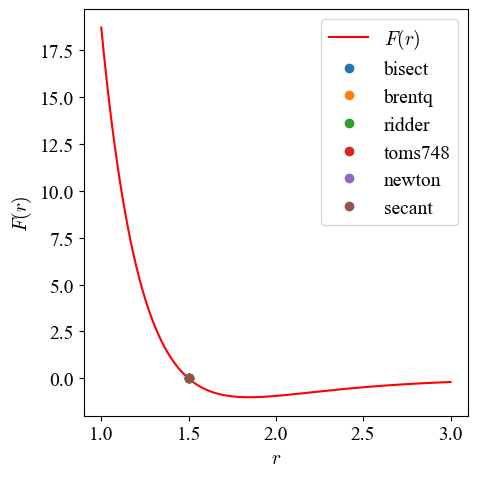

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(r, F(r), color="r", label=r"$F(r)$")
for name, sol in methods.items():
    plt.plot(sol.root, 0, "o", label=name)
plt.xlabel(r"$r$")
plt.ylabel(r"$F(r)$")
plt.legend()
plt.tight_layout()
plt.show()

The estimated equilibrium bond distance is also shown on the Morse potential, illustrating that the equilibrium bond distance obtained from the root-finding algorithms coincides with the minimum of the Morse potential.

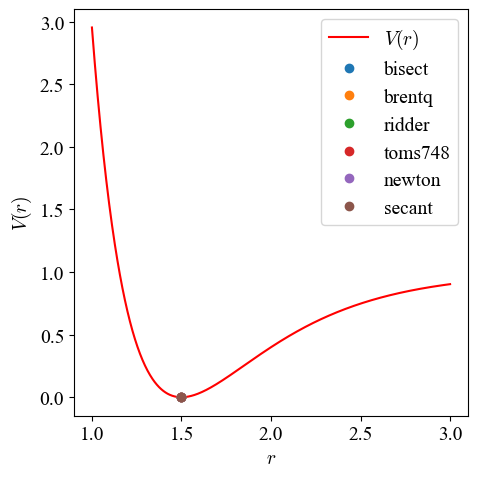

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(r, V(r), color="r", label=r"$V(r)$")
for name, sol in methods.items():
    plt.plot(sol.root, 0, "o", label=name)
plt.xlabel(r"$r$")
plt.ylabel(r"$V(r)$")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

* Root finding determines numerical solutions satisfying $f(r)=0$.
* For the Morse potential, the equilibrium bond distance corresponds to the minimum of the potential energy, where the interatomic force satisfies $F(r)=0$.
* Bracketing methods provide guaranteed convergence when the root is enclosed, whereas open methods generally converge faster with suitable initial estimates.